In [ ]:
# ============================================
# ЛАБОРАТОРНАЯ РАБОТА №1
# ПРЕДОБРАБОТКА И ОЧИСТКА ДАННЫХ
# Датасет: bank-additional-full.csv
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


In [ ]:
# ============================================
# ЗАГРУЗКА ДАТАСЕТА
# ============================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    sep=';'
)

print("Файл:", file_name)
print("Размер датасета:", df.shape)

display(df.head())

Saving bank-additional-full.csv to bank-additional-full (1).csv
Файл: bank-additional-full (1).csv
Размер датасета: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# ============================================
# ИНФОРМАЦИЯ О ДАННЫХ
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
# ============================================
# ПЕРВИЧНЫЙ АНАЛИЗ
# ============================================

print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nПервые 5 строк:")
display(df.head())

print("\nПоследние 5 строк:")
display(df.tail())

Количество строк: 41188
Количество столбцов: 21

Названия столбцов:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Первые 5 строк:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Последние 5 строк:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
# ============================================
# ТИПЫ ДАННЫХ
# ============================================

type_table = pd.DataFrame({
    'Столбец': df.columns,
    'Тип данных': df.dtypes.astype(str).values,
    'Количество уникальных значений': [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

display(type_table)

,Столбец,Тип данных,Количество уникальных значений
0,age,int64,78
1,job,object,12
2,marital,object,4
3,education,object,8
4,default,object,3
5,housing,object,3
6,loan,object,3
7,contact,object,2
8,month,object,10
9,day_of_week,object,5


In [ ]:
# ============================================
# ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ============================================

print("Статистика числовых признаков:")

display(df.describe())

Статистика числовых признаков:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
# ============================================
# СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ============================================

print("Статистика категориальных признаков:")

display(df.describe(include='object'))

Статистика категориальных признаков:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [ ]:
# ============================================
# UNKNOWN = ПРОПУСКИ
# ============================================

unknown_count = (df == 'unknown').sum()

print("Количество unknown по столбцам:")

display(
    unknown_count[
        unknown_count > 0
    ].sort_values(ascending=False)
)

print(
    "Общее количество unknown:",
    unknown_count.sum()
)

Количество unknown по столбцам:


,0
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


Общее количество unknown: 12718


In [ ]:
# ============================================
# ВСЕ ПРОПУСКИ
# ============================================

total_missing = (
    df.isnull().sum()
    + (df == 'unknown').sum()
)

missing_table = pd.DataFrame({
    'Количество пропусков': total_missing,
    'Процент пропусков': (
        total_missing / len(df) * 100
    ).round(2)
})

missing_table = missing_table[
    missing_table['Количество пропусков'] > 0
].sort_values(
    'Количество пропусков',
    ascending=False
)

display(missing_table)

print(
    "Всего пропусков:",
    total_missing.sum()
)

,Количество пропусков,Процент пропусков
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


Всего пропусков: 12718


In [ ]:
# ============================================
# ПРЕОБРАЗОВАНИЕ UNKNOWN В NaN
# ============================================

df_clean = df.copy()

df_clean = df_clean.replace('unknown', np.nan)

print("После замены unknown на NaN:")

display(
    df_clean.isnull().sum()
    .sort_values(ascending=False)
)

После замены unknown на NaN:


,0
default,8597
education,1731
housing,990
loan,990
job,330
marital,80
age,0
contact,0
month,0
day_of_week,0


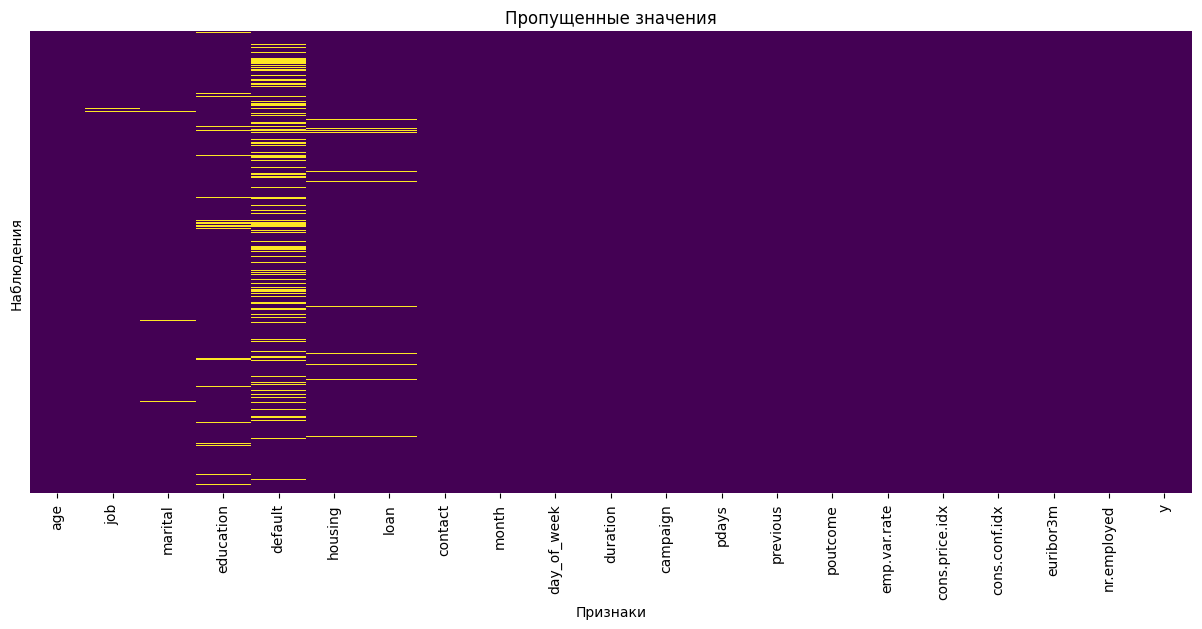

In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ ПРОПУСКОВ
# ============================================

plt.figure(figsize=(15, 6))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title('Пропущенные значения')
plt.xlabel('Признаки')
plt.ylabel('Наблюдения')

plt.show()

In [ ]:
# ============================================
# ДУБЛИКАТЫ
# ============================================

duplicate_count = df_clean.duplicated().sum()

print("Количество полных дубликатов:", duplicate_count)

print(
    "Процент дубликатов:",
    round(
        duplicate_count / len(df_clean) * 100,
        2
    ),
    "%"
)

Количество полных дубликатов: 12
Процент дубликатов: 0.03 %


In [ ]:
# ============================================
# ПРОСМОТР ДУБЛИКАТОВ
# ============================================

duplicates = df_clean[
    df_clean.duplicated(keep=False)
]

print("Повторяющиеся строки:")

display(duplicates.head(20))

Повторяющиеся строки:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,NaN,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,NaN,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [ ]:
# ============================================
# УДАЛЕНИЕ ДУБЛИКАТОВ
# ============================================

rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(
    drop=True
)

rows_after = len(df_clean)

print("Строк до удаления:", rows_before)
print("Строк после удаления:", rows_after)
print("Удалено дубликатов:", rows_before - rows_after)

Строк до удаления: 41188
Строк после удаления: 41176
Удалено дубликатов: 12


In [ ]:
# ============================================
# ЧАСТИЧНЫЕ ДУБЛИКАТЫ
# ============================================

# 1. По age + job + marital
cols = ['age', 'job', 'marital']

# Количество строк, которые входят в повторяющиеся группы
partial_rows = df_clean[
    df_clean.duplicated(
        subset=cols,
        keep=False
    )
]

print("Количество строк, входящих в повторяющиеся группы:",
      len(partial_rows))

# 2. Количество самих повторяющихся комбинаций
groups = (
    df_clean
    .groupby(cols)
    .size()
    .reset_index(name='Количество')
)

repeated_groups = groups[
    groups['Количество'] > 1
]

print("Количество повторяющихся комбинаций:",
      len(repeated_groups))

# 3. Сколько лишних повторений сверх первой записи
extra_duplicates = (
    repeated_groups['Количество'] - 1
).sum()

print("Количество лишних повторений:",
      extra_duplicates)

# Показываем несколько групп
display(
    repeated_groups
    .sort_values('Количество', ascending=False)
    .head(20)
)

Количество строк, входящих в повторяющиеся группы: 41042
Количество повторяющихся комбинаций: 1109
Количество лишних повторений: 39933


,age,job,marital,Количество
172,29,admin.,single,382
377,36,blue-collar,married,344
346,35,blue-collar,married,315
229,31,admin.,single,308
258,32,admin.,single,305
286,33,admin.,married,299
319,34,blue-collar,married,297
201,30,admin.,single,287
529,41,blue-collar,married,286
316,34,admin.,married,283


In [ ]:
# ============================================
# НОРМАЛИЗАЦИЯ КАТЕГОРИЙ
# ============================================

categorical_columns = df_clean.select_dtypes(
    include='object'
).columns.tolist()

for col in categorical_columns:

    df_clean[col] = df_clean[col].apply(
        lambda x: x.strip().lower()
        if isinstance(x, str)
        else x
    )

print("Категориальные значения нормализованы.")

Категориальные значения нормализованы.


In [ ]:
# ============================================
# ПРИЗНАКИ
# ============================================

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df_clean.select_dtypes(
    include='object'
).columns.tolist()

print("Числовые признаки:")
print(numeric_columns)

print("\nКатегориальные признаки:")
print(categorical_columns)

Числовые признаки:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Категориальные признаки:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [ ]:
# ============================================
# ЗАПОЛНЕНИЕ ПРОПУСКОВ
# ============================================

# Числовые признаки
for col in numeric_columns:

    median_value = df_clean[col].median()

    df_clean[col] = df_clean[col].fillna(
        median_value
    )


# Категориальные признаки
for col in categorical_columns:

    mode_value = df_clean[col].mode()

    if len(mode_value) > 0:

        df_clean[col] = df_clean[col].fillna(
            mode_value.iloc[0]
        )


print("Пропуски заполнены.")

Пропуски заполнены.


In [ ]:
# ============================================
# ПРОВЕРКА ПОСЛЕ ЗАПОЛНЕНИЯ
# ============================================

remaining_missing = df_clean.isnull().sum()

print("Оставшиеся пропуски:")

display(
    remaining_missing[
        remaining_missing > 0
    ]
)

print(
    "Общее количество оставшихся пропусков:",
    remaining_missing.sum()
)

Оставшиеся пропуски:


,0


Общее количество оставшихся пропусков: 0


In [ ]:
# ============================================
# ПРОВЕРКА ДИАПАЗОНОВ
# ============================================

if 'age' in df_clean.columns:

    print(
        "Отрицательный возраст:",
        (df_clean['age'] < 0).sum()
    )

    print(
        "Возраст больше 100:",
        (df_clean['age'] > 100).sum()
    )


if 'duration' in df_clean.columns:

    print(
        "Отрицательная duration:",
        (df_clean['duration'] < 0).sum()
    )


if 'campaign' in df_clean.columns:

    print(
        "Отрицательная campaign:",
        (df_clean['campaign'] < 0).sum()
    )


if 'previous' in df_clean.columns:

    print(
        "Отрицательная previous:",
        (df_clean['previous'] < 0).sum()
    )

Отрицательный возраст: 0
Возраст больше 100: 0
Отрицательная duration: 0
Отрицательная campaign: 0
Отрицательная previous: 0


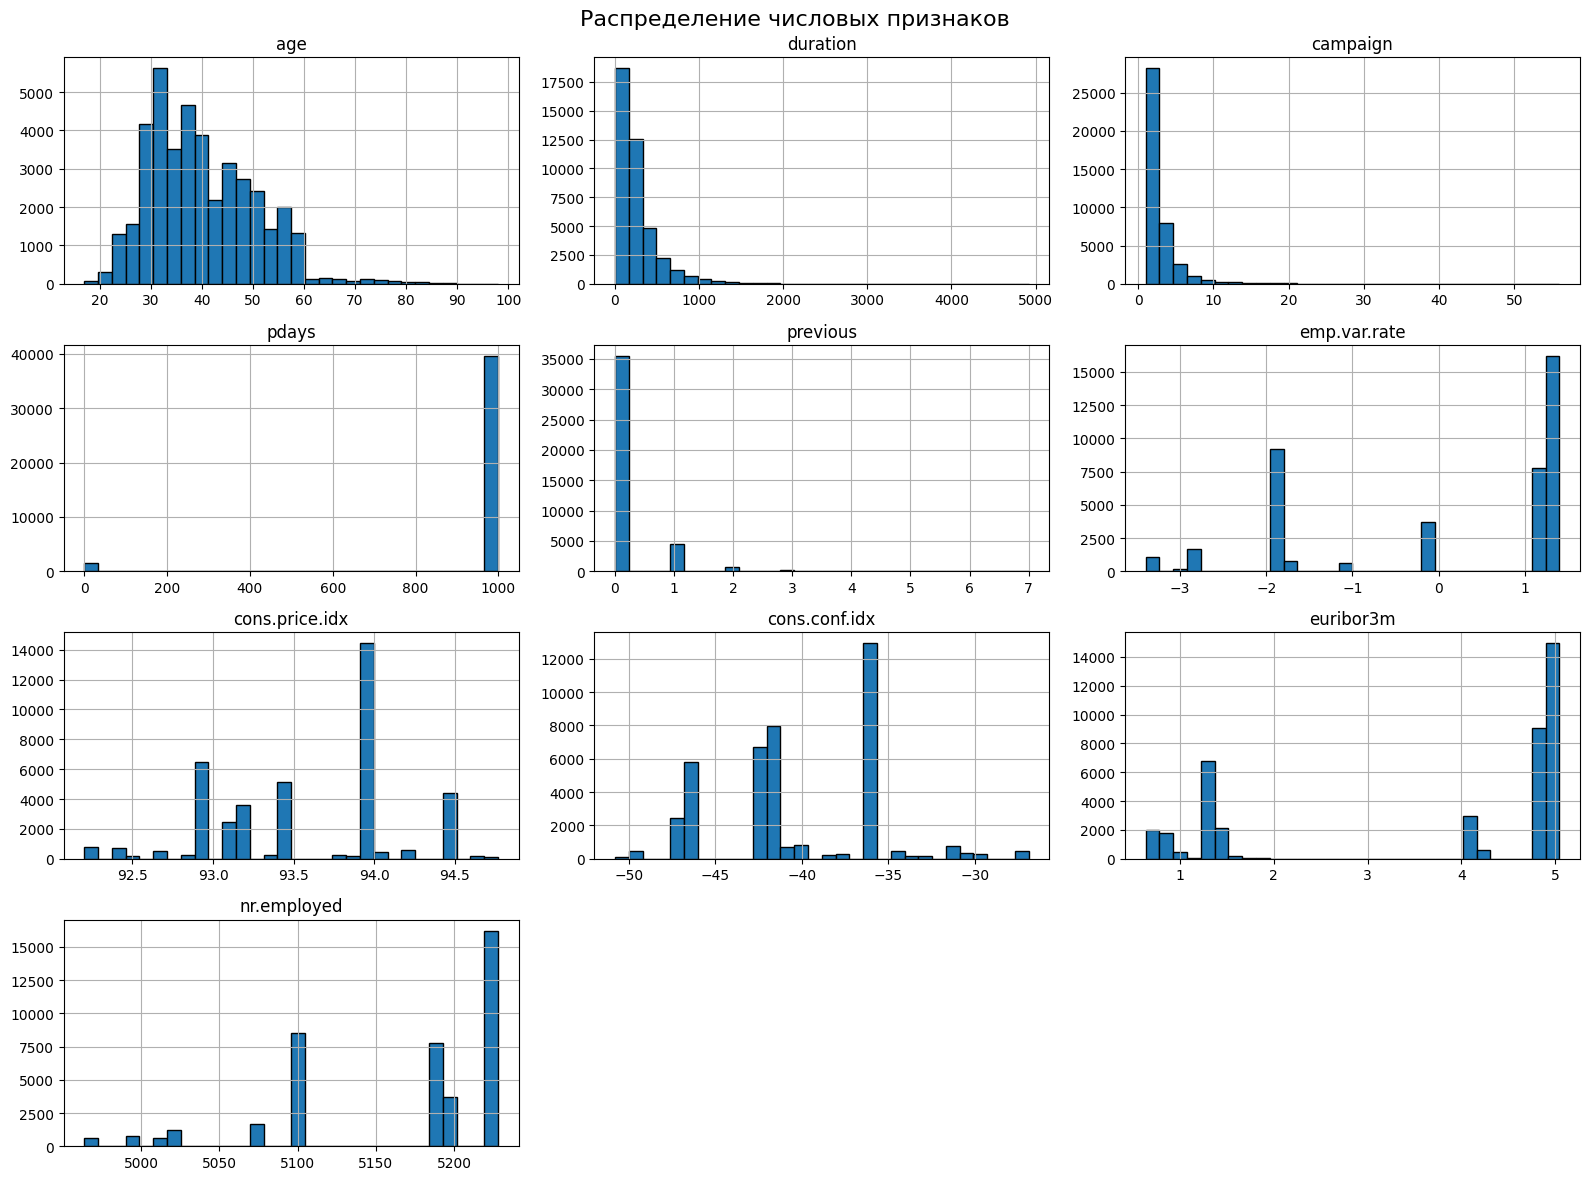

In [ ]:
# ============================================
# ГИСТОГРАММЫ
# ============================================

df_clean[numeric_columns].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    'Распределение числовых признаков',
    fontsize=16
)

plt.tight_layout()
plt.show()

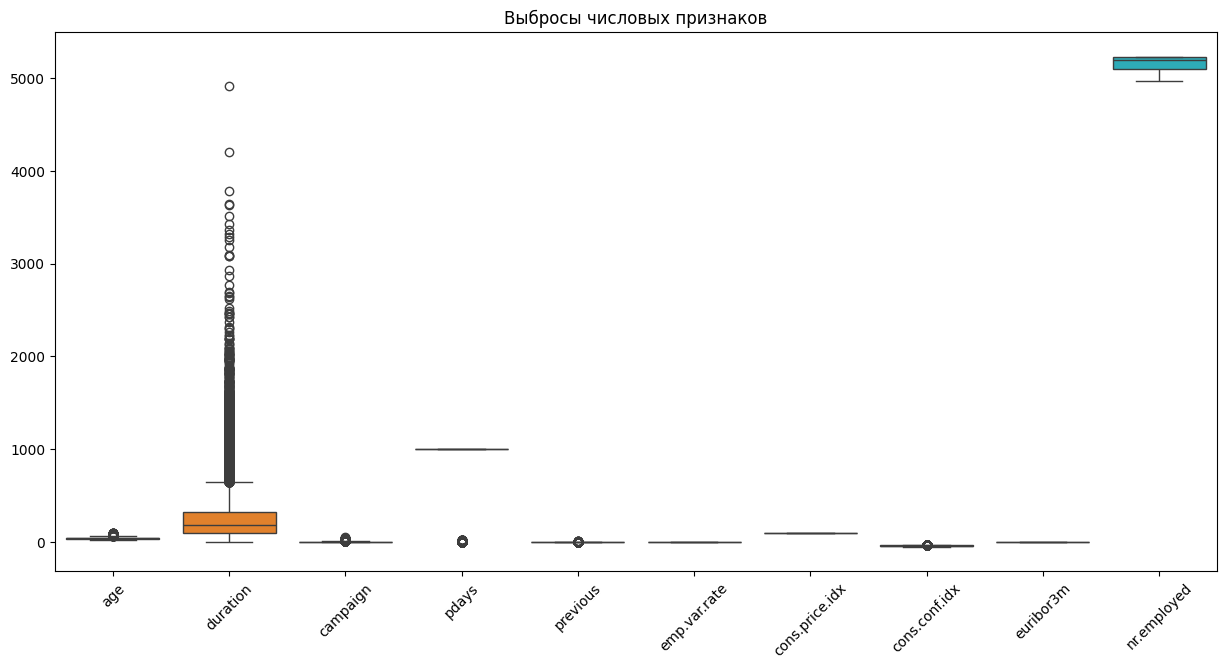

In [ ]:
# ============================================
# BOX PLOT
# ============================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df_clean[numeric_columns]
)

plt.title(
    'Выбросы числовых признаков'
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================
# IQR
# ============================================

def detect_iqr_outliers(data, columns):

    results = {}

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (data[col] < lower) |
            (data[col] > upper)
        )

        results[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Нижняя граница': lower,
            'Верхняя граница': upper,
            'Количество выбросов': int(
                outliers.sum()
            ),
            'Процент выбросов': round(
                outliers.mean() * 100,
                2
            )
        }

    return pd.DataFrame(results).T


iqr_results = detect_iqr_outliers(
    df_clean,
    numeric_columns
)

display(iqr_results)

,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Количество выбросов,Процент выбросов
age,32.000,47.000,15.000,9.5000,69.5000,468.0,1.14
duration,102.000,319.000,217.000,-223.5000,644.5000,2963.0,7.20
campaign,1.000,3.000,2.000,-2.0000,6.0000,2406.0,5.84
pdays,999.000,999.000,0.000,999.0000,999.0000,1515.0,3.68
previous,0.000,0.000,0.000,0.0000,0.0000,5625.0,13.66
emp.var.rate,-1.800,1.400,3.200,-6.6000,6.2000,0.0,0.00
cons.price.idx,93.075,93.994,0.919,91.6965,95.3725,0.0,0.00
cons.conf.idx,-42.700,-36.400,6.300,-52.1500,-26.9500,446.0,1.08
euribor3m,1.344,4.961,3.617,-4.0815,10.3865,0.0,0.00
nr.employed,5099.100,5228.100,129.000,4905.6000,5421.6000,0.0,0.00


In [ ]:
# ============================================
# Z-SCORE
# ============================================

zscore_results = {}

for col in numeric_columns:

    z_scores = zscore(
        df_clean[col]
    )

    outliers = np.abs(z_scores) > 3

    zscore_results[col] = {
        'Количество выбросов': int(
            outliers.sum()
        ),
        'Процент выбросов': round(
            outliers.mean() * 100,
            2
        )
    }


zscore_table = pd.DataFrame(
    zscore_results
).T

display(zscore_table)

,Количество выбросов,Процент выбросов
age,369.0,0.90
duration,861.0,2.09
campaign,869.0,2.11
pdays,1515.0,3.68
previous,1064.0,2.58
emp.var.rate,0.0,0.00
cons.price.idx,0.0,0.00
cons.conf.idx,0.0,0.00
euribor3m,0.0,0.00
nr.employed,0.0,0.00


In [ ]:
# ============================================
# СРАВНЕНИЕ МЕТОДОВ
# ============================================

outlier_comparison = pd.DataFrame(
    index=numeric_columns
)

outlier_comparison['IQR'] = [
    iqr_results.loc[
        col,
        'Количество выбросов'
    ]
    for col in numeric_columns
]

outlier_comparison['Z-score'] = [
    zscore_table.loc[
        col,
        'Количество выбросов'
    ]
    for col in numeric_columns
]

display(outlier_comparison)

,IQR,Z-score
age,468.0,369.0
duration,2963.0,861.0
campaign,2406.0,869.0
pdays,1515.0,1515.0
previous,5625.0,1064.0
emp.var.rate,0.0,0.0
cons.price.idx,0.0,0.0
cons.conf.idx,446.0,0.0
euribor3m,0.0,0.0
nr.employed,0.0,0.0


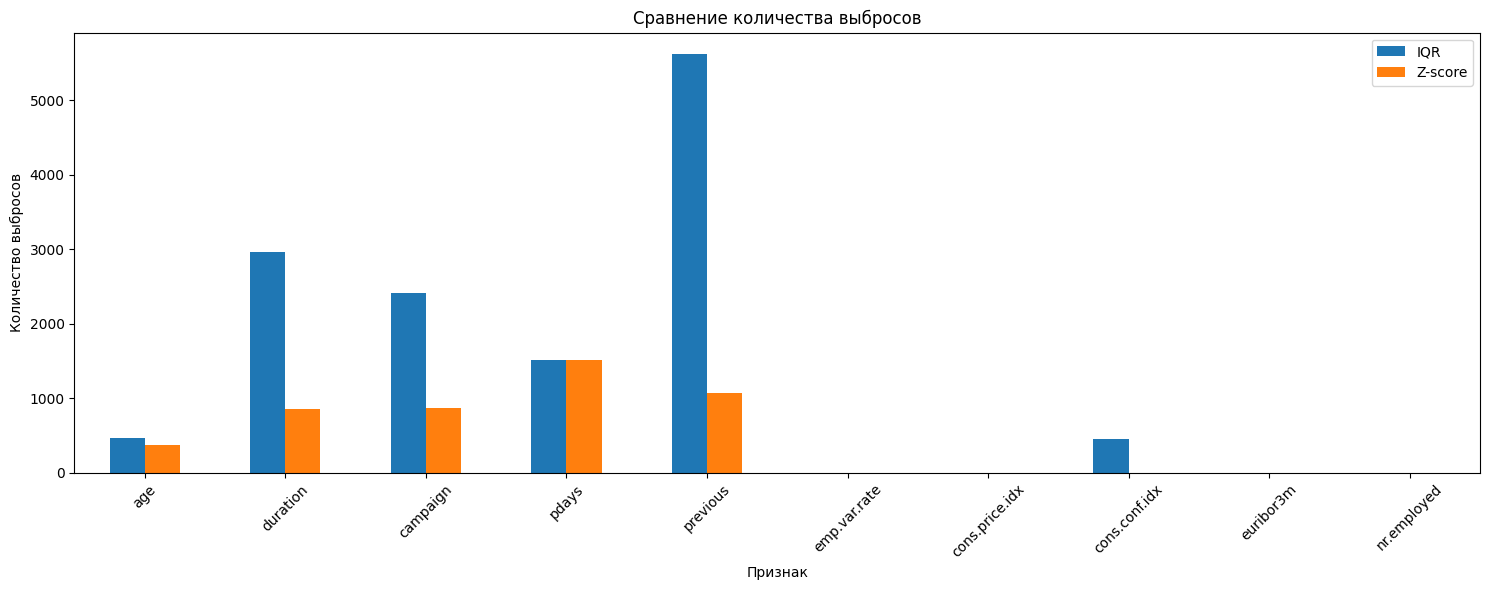

In [ ]:
# ============================================
# ГРАФИК ВЫБРОСОВ
# ============================================

outlier_comparison.plot(
    kind='bar',
    figsize=(15, 6)
)

plt.title(
    'Сравнение количества выбросов'
)

plt.xlabel('Признак')
plt.ylabel('Количество выбросов')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# ОБРАБОТКА ВЫБРОСОВ
# ============================================

df_outliers_clean = df_clean.copy()

for col in numeric_columns:

    Q1 = df_outliers_clean[col].quantile(0.25)
    Q3 = df_outliers_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_outliers_clean[col] = (
        df_outliers_clean[col]
        .clip(
            lower=lower,
            upper=upper
        )
    )

print("Выбросы обработаны.")

Выбросы обработаны.


In [ ]:
# ============================================
# ПРОВЕРКА ВЫБРОСОВ ПОСЛЕ ОБРАБОТКИ
# ============================================

iqr_after = detect_iqr_outliers(
    df_outliers_clean,
    numeric_columns
)

display(iqr_after)

,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Количество выбросов,Процент выбросов
age,32.000,47.000,15.000,9.5000,69.5000,0.0,0.0
duration,102.000,319.000,217.000,-223.5000,644.5000,0.0,0.0
campaign,1.000,3.000,2.000,-2.0000,6.0000,0.0,0.0
pdays,999.000,999.000,0.000,999.0000,999.0000,0.0,0.0
previous,0.000,0.000,0.000,0.0000,0.0000,0.0,0.0
emp.var.rate,-1.800,1.400,3.200,-6.6000,6.2000,0.0,0.0
cons.price.idx,93.075,93.994,0.919,91.6965,95.3725,0.0,0.0
cons.conf.idx,-42.700,-36.400,6.300,-52.1500,-26.9500,0.0,0.0
euribor3m,1.344,4.961,3.617,-4.0815,10.3865,0.0,0.0
nr.employed,5099.100,5228.100,129.000,4905.6000,5421.6000,0.0,0.0


In [ ]:
# ============================================
# СРАВНЕНИЕ СТАТИСТИКИ
# ============================================

before_stats = df.describe().T

after_stats = df_outliers_clean.describe().T

stats_comparison = pd.DataFrame({

    'Среднее ДО':
        before_stats['mean'],

    'Среднее ПОСЛЕ':
        after_stats['mean'],

    'Медиана ДО':
        before_stats['50%'],

    'Медиана ПОСЛЕ':
        after_stats['50%'],

    'Ст. отклонение ДО':
        before_stats['std'],

    'Ст. отклонение ПОСЛЕ':
        after_stats['std'],

    'Минимум ДО':
        before_stats['min'],

    'Минимум ПОСЛЕ':
        after_stats['min'],

    'Максимум ДО':
        before_stats['max'],

    'Максимум ПОСЛЕ':
        after_stats['max']
})

display(stats_comparison)

,Среднее ДО,Среднее ПОСЛЕ,Медиана ДО,Медиана ПОСЛЕ,Ст. отклонение ДО,Ст. отклонение ПОСЛЕ,Минимум ДО,Минимум ПОСЛЕ,Максимум ДО,Максимум ПОСЛЕ
age,40.024060,39.939236,38.000,38.000,10.421250,10.128801,17.000,17.000,98.000,69.500
duration,258.285010,235.021335,180.000,180.000,259.279249,177.365635,0.000,0.000,4918.000,644.500
campaign,2.567593,2.275476,2.000,2.000,2.770014,1.550606,1.000,1.000,56.000,6.000
pdays,962.475454,999.000000,999.000,999.000,186.910907,0.000000,0.000,999.000,999.000,999.000
previous,0.172963,0.000000,0.000,0.000,0.494901,0.000000,0.000,0.000,7.000,0.000
emp.var.rate,0.081886,0.081922,1.100,1.100,1.570960,1.570883,-3.400,-3.400,1.400,1.400
cons.price.idx,93.575664,93.575720,93.749,93.749,0.578840,0.578839,92.201,92.201,94.767,94.767
cons.conf.idx,-40.502600,-40.503405,-41.800,-41.800,4.628198,4.626271,-50.800,-50.800,-26.900,-26.950
euribor3m,3.621291,3.621293,4.857,4.857,1.734447,1.734437,0.634,0.634,5.045,5.045
nr.employed,5167.035911,5167.034870,5191.000,5191.000,72.251528,72.251364,4963.600,4963.600,5228.100,5228.100


In [ ]:
# ============================================
# РАЗМЕРЫ ДО И ПОСЛЕ
# ============================================

print(
    "Исходный датасет:",
    df.shape
)

print(
    "После удаления дубликатов:",
    df_clean.shape
)

print(
    "После обработки выбросов:",
    df_outliers_clean.shape
)

Исходный датасет: (41188, 21)
После удаления дубликатов: (41176, 21)
После обработки выбросов: (41176, 21)


In [ ]:
# ============================================
# СОЗДАНИЕ ГРЯЗНОГО ДАТАСЕТА
# ============================================

np.random.seed(42)

df_original = df.copy()

df_dirty = df_original.copy()

print(
    "Исходный размер:",
    df_dirty.shape
)

Исходный размер: (41188, 21)


In [ ]:
# ============================================
# ИСКУССТВЕННЫЕ ПРОПУСКИ
# ============================================

missing_fraction = 0.07

n_missing = int(
    len(df_dirty) * missing_fraction
)

missing_rows = np.random.choice(
    len(df_dirty),
    size=n_missing,
    replace=False
)

if 'age' in df_dirty.columns:

    df_dirty.loc[
        missing_rows,
        'age'
    ] = np.nan


if 'job' in df_dirty.columns:

    df_dirty.loc[
        missing_rows,
        'job'
    ] = np.nan


print(
    "Добавлено искусственных пропусков:",
    n_missing
)

Добавлено искусственных пропусков: 2883


In [ ]:
# ============================================
# ИСКУССТВЕННЫЕ ДУБЛИКАТЫ
# ============================================

duplicate_rows = df_dirty.sample(
    20,
    random_state=42
)

df_dirty = pd.concat(
    [
        df_dirty,
        duplicate_rows
    ],
    ignore_index=True
)

print(
    "Количество дубликатов:",
    df_dirty.duplicated().sum()
)

print(
    "Размер после добавления дубликатов:",
    df_dirty.shape
)

Количество дубликатов: 31
Размер после добавления дубликатов: (41208, 21)


In [ ]:
# ============================================
# ИСКУССТВЕННЫЕ ВЫБРОСЫ
# ============================================

if 'age' in df_dirty.columns:

    df_dirty.loc[0, 'age'] = 999
    df_dirty.loc[1, 'age'] = -10


if 'campaign' in df_dirty.columns:

    df_dirty.loc[2, 'campaign'] = 1000


if 'duration' in df_dirty.columns:

    df_dirty.loc[3, 'duration'] = 99999


print("Искусственные выбросы добавлены.")

Искусственные выбросы добавлены.


In [ ]:
# ============================================
# ОШИБКИ В КАТЕГОРИАЛЬНЫХ ДАННЫХ
# ============================================

if 'job' in df_dirty.columns:

    df_dirty.loc[4, 'job'] = ' admin. '
    df_dirty.loc[5, 'job'] = 'ADMIN'
    df_dirty.loc[6, 'job'] = 'Admin'


if 'marital' in df_dirty.columns:

    df_dirty.loc[7, 'marital'] = ' married '


print("Ошибки категориальных данных добавлены.")

Ошибки категориальных данных добавлены.


In [ ]:
# ============================================
# НЕПРАВИЛЬНЫЙ ТИП
# ============================================

if 'age' in df_dirty.columns:

    df_dirty['age'] = (
        df_dirty['age']
        .astype(str)
    )

print(
    "Тип age:",
    df_dirty['age'].dtype
)

Тип age: object


In [ ]:
# ============================================
# АУДИТ ГРЯЗНОГО ДАТАСЕТА
# ============================================

print("Размер:", df_dirty.shape)

print(
    "\nКоличество NaN:",
    df_dirty.isnull().sum().sum()
)

print(
    "Количество unknown:",
    (df_dirty == 'unknown').sum().sum()
)

print(
    "Количество дубликатов:",
    df_dirty.duplicated().sum()
)

print("\nТипы данных:")

display(df_dirty.dtypes)

Размер: (41208, 21)

Количество NaN: 2903
Количество unknown: 12699
Количество дубликатов: 31

Типы данных:


,0
age,object
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [ ]:
# ============================================
# ИСПРАВЛЕНИЕ ТИПА AGE
# ============================================

df_recovered = df_dirty.copy()

df_recovered['age'] = pd.to_numeric(
    df_recovered['age'],
    errors='coerce'
)

print(
    "Тип age после исправления:",
    df_recovered['age'].dtype
)

Тип age после исправления: float64


In [ ]:
# ============================================
# ОБРАБОТКА UNKNOWN
# ============================================

df_recovered = df_recovered.replace(
    'unknown',
    np.nan
)

print(
    "Пропуски после обработки unknown:",
    df_recovered.isnull().sum().sum()
)

Пропуски после обработки unknown: 18504


In [ ]:
# ============================================
# НОРМАЛИЗАЦИЯ КАТЕГОРИЙ
# ============================================

categorical_recovered = df_recovered.select_dtypes(
    include='object'
).columns.tolist()

for col in categorical_recovered:

    df_recovered[col] = df_recovered[col].apply(
        lambda x:
        x.strip().lower()
        if isinstance(x, str)
        else x
    )

print("Категориальные значения нормализованы.")

Категориальные значения нормализованы.


In [ ]:
# ============================================
# УДАЛЕНИЕ ДУБЛИКАТОВ
# ============================================

before_duplicates = len(df_recovered)

df_recovered = (
    df_recovered
    .drop_duplicates()
    .reset_index(drop=True)
)

after_duplicates = len(df_recovered)

print(
    "До удаления:",
    before_duplicates
)

print(
    "После удаления:",
    after_duplicates
)

print(
    "Удалено:",
    before_duplicates - after_duplicates
)

До удаления: 41208
После удаления: 41177
Удалено: 31


In [ ]:
# ============================================
# ИСПРАВЛЕНИЕ ВОЗРАСТА
# ============================================

if 'age' in df_recovered.columns:

    df_recovered.loc[
        (df_recovered['age'] < 18) |
        (df_recovered['age'] > 100),
        'age'
    ] = np.nan


print("Некорректный возраст заменён на NaN.")

Некорректный возраст заменён на NaN.


In [ ]:
# ============================================
# ИСПРАВЛЕНИЕ НЕКОРРЕКТНЫХ ЗНАЧЕНИЙ
# ============================================

if 'duration' in df_recovered.columns:

    df_recovered.loc[
        df_recovered['duration'] < 0,
        'duration'
    ] = np.nan


if 'campaign' in df_recovered.columns:

    df_recovered.loc[
        df_recovered['campaign'] < 0,
        'campaign'
    ] = np.nan


if 'previous' in df_recovered.columns:

    df_recovered.loc[
        df_recovered['previous'] < 0,
        'previous'
    ] = np.nan


print("Некорректные значения обработаны.")

Некорректные значения обработаны.


In [ ]:
# ============================================
# ЗАПОЛНЕНИЕ ПРОПУСКОВ ПОСЛЕ ОЧИСТКИ
# ============================================

numeric_recovered = df_recovered.select_dtypes(
    include=np.number
).columns.tolist()

categorical_recovered = df_recovered.select_dtypes(
    include='object'
).columns.tolist()


# Числовые
for col in numeric_recovered:

    df_recovered[col] = (
        df_recovered[col]
        .fillna(
            df_recovered[col].median()
        )
    )


# Категориальные
for col in categorical_recovered:

    mode = df_recovered[col].mode()

    if len(mode) > 0:

        df_recovered[col] = (
            df_recovered[col]
            .fillna(mode.iloc[0])
        )


print("Пропуски заполнены.")

Пропуски заполнены.


In [ ]:
# ============================================
# ОБРАБОТКА ВЫБРОСОВ
# ============================================

for col in numeric_recovered:

    Q1 = df_recovered[col].quantile(0.25)

    Q3 = df_recovered[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df_recovered[col] = (
        df_recovered[col]
        .clip(
            lower=lower,
            upper=upper
        )
    )


print("Выбросы обработаны.")

Выбросы обработаны.


In [ ]:
# ============================================
# ФИНАЛЬНЫЙ АУДИТ
# ============================================

print("================================")
print("ДО ОЧИСТКИ")
print("================================")

print(
    "Размер:",
    df_dirty.shape
)

print(
    "NaN:",
    df_dirty.isnull().sum().sum()
)

print(
    "unknown:",
    (df_dirty == 'unknown').sum().sum()
)

print(
    "Дубликаты:",
    df_dirty.duplicated().sum()
)


print("\n================================")
print("ПОСЛЕ ОЧИСТКИ")
print("================================")

print(
    "Размер:",
    df_recovered.shape
)

print(
    "NaN:",
    df_recovered.isnull().sum().sum()
)

print(
    "Дубликаты:",
    df_recovered.duplicated().sum()
)

print("\nТипы данных:")

display(df_recovered.dtypes)

ДО ОЧИСТКИ
Размер: (41208, 21)
NaN: 2903
unknown: 12699
Дубликаты: 31

ПОСЛЕ ОЧИСТКИ
Размер: (41177, 21)
NaN: 0
Дубликаты: 13

Типы данных:


,0
age,float64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [ ]:
# ============================================
# ИТОГОВОЕ СРАВНЕНИЕ
# ============================================

final_comparison = pd.DataFrame({

    'Показатель': [
        'Количество строк',
        'Количество столбцов',
        'Пропуски',
        'Дубликаты'
    ],

    'До очистки': [
        df_dirty.shape[0],
        df_dirty.shape[1],
        df_dirty.isnull().sum().sum(),
        df_dirty.duplicated().sum()
    ],

    'После очистки': [
        df_recovered.shape[0],
        df_recovered.shape[1],
        df_recovered.isnull().sum().sum(),
        df_recovered.duplicated().sum()
    ]
})

display(final_comparison)

,Показатель,До очистки,После очистки
0,Количество строк,41208,41177
1,Количество столбцов,21,21
2,Пропуски,2903,0
3,Дубликаты,31,13
